In [17]:
import tensorflow as tf

In [19]:
from sklearn.datasets import fetch_california_housing
import numpy as np
housing = fetch_california_housing(as_frame=True)
X = housing.data.values.astype(np.float32)
y = housing.target.values.astype(np.float32)
print(f" features:{housing.feature_names}")
print(f"shape: x={X.shape}| y ={y.shape}")
print(f"target range: {y.min():.2f} - {y.max():.2f} ($100k)")

 features:['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
shape: x=(20640, 8)| y =(20640,)
target range: 0.15 - 5.00 ($100k)


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_temp, X_test, y_temp, y_test = train_test_split(
    X,  y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
print(f"\nTtrain :{X_train.shape[0]} | val: {X_val.shape[0]} Test: {X_test.shape[0]}")


Ttrain :14912 | val: 2632 Test: 3096


In [21]:
def build_house_models(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="features")

    X= keras.layers.Dense(256)(inputs)
    X= keras.layers.BatchNormalization()(X)
    X= keras.layers.Activation("relu")(X)
    X= keras.layers.Dropout(0.2)(X)


    X= keras.layers.Dense(128)(inputs)
    X= keras.layers.BatchNormalization()(X)
    X= keras.layers.Activation("relu")(X)
    X= keras.layers.Dropout(0.2)(X)

    X= keras.layers.Dense(64)(inputs)
    X= keras.layers.BatchNormalization()(X)
    X= keras.layers.Activation("relu")(X)
    X= keras.layers.Dropout(0.2)(X)


    outputs = keras.layers.Dense(1, name="price_output")(X)
    return keras.Model(inputs, outputs, name="HousePriceANN")
   

In [22]:
 model = build_house_models(input_dim=8)
 model.summary()

Model: "HousePriceANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ price_output (Dense)                 │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 128 (512.00 B)

<h3>Compile<h3/>

In [23]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss = "mse",
    metrics = ["mae"]
)

In [24]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=25,
        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=7,
        min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "best_house_model.keras", monitor="val_loss",
        save_best_only = True, verbose=0
    )
]

<h2> Train <h2/>

In [25]:
history = model.fit(
    X_train, y_train,
    epochs = 200, batch_size=256,
    validation_data=(X_val, y_val),
    callbacks = callbacks, verbose=1
)

Epoch 1/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.9073 - mae: 1.2436 - val_loss: 2.1301 - val_mae: 1.0807 - learning_rate: 0.0010
Epoch 2/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2102 - mae: 0.7890 - val_loss: 1.3357 - val_mae: 0.8340 - learning_rate: 0.0010
Epoch 3/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9873 - mae: 0.7340 - val_loss: 1.0206 - val_mae: 0.7190 - learning_rate: 0.0010
Epoch 4/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9027 - mae: 0.6979 - val_loss: 0.8341 - val_mae: 0.6475 - learning_rate: 0.0010
Epoch 5/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8288 - mae: 0.6647 - val_loss: 0.7130 - val_mae: 0.5952 - learning_rate: 0.0010
Epoch 6/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7950 - mae: 0.6547 - val_loss: 0.6461 - val_mae: 0.5620 - learning_rate: 0.0010
Epoch 7/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7362 - mae: 0.6274 - val_loss: 0.6225 - val_mae: 0.5473 - learning_rate: 0.0010
Epoch 8/200
5

In [31]:
from sklearn.metrics import r2_score
results =model.evaluate(X_test, y_test, verbose=0)
print(f"\n===Test Result")
print(f"MSE :{results[0]: .4f}")
print(f"MAE :{results[1]:.4f} (${results[1]*100: .0f} k average error)")
y_pred = model.predict(X_test, verbose=0).flatten()
r2 = r2_score(y_test, y_pred)
print(f"R**2: {r2:4f}(1.0 = perfect)")



===Test Result
MSE : 0.4903
MAE :0.4826 ($ 48 k average error)
R**2: 0.625892(1.0 = perfect)


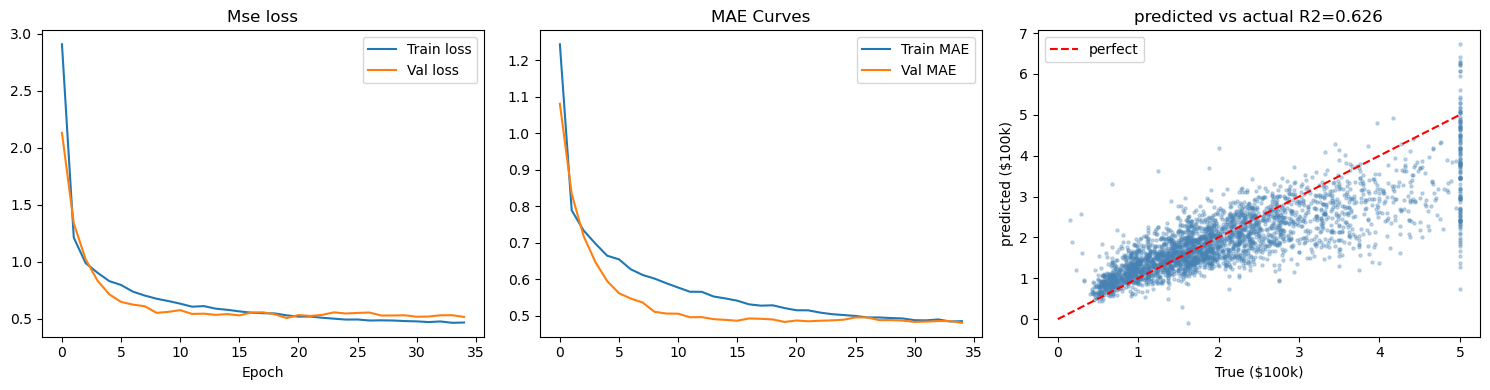

In [34]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history.history["loss"], label='Train loss')
axes[0].plot(history.history["val_loss"], label='Val loss')
axes[0].set_title("Mse loss")
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(history.history["mae"], label='Train MAE')
axes[1].plot(history.history["val_mae"], label='Val MAE')
axes[1].set_title("MAE Curves")
axes[1].legend()
axes[2].scatter(y_test, y_pred, alpha=0.3, s=5, color="steelblue")
axes[2].plot([0,5],[0,5], "r--", label='perfect')
axes[2].set_xlabel('True ($100k)')
axes[2].set_ylabel('predicted ($100k)')
axes[2].set_title(f'predicted vs actual R2={r2:.3f}')
axes[2].legend()
plt.tight_layout()
plt.savefig('house_price_result.png', dpi=150)
plt.show()